## Ejercicio 1. 

Realizar un modelo para clasificar si es una espícula maligna o venigna. Debera realizar dividir en 60%, 70%, 80% y comparar la exactitud de los modelos.

## 1. Import libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
# 1. Cargar el archivo CSV en un DataFrame
df = pd.read_csv('Data/breast_data_raw.csv')

# Mostrar la dimensión del dataset y las primeras 5 filas
print("Dimensiones del dataset:", df.shape)
print(df.head(5))

Dimensiones del dataset: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M          NaN         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  textu

In [16]:

# 1.1. Manejar valores Nan y eliminar columna ID

# Eliminar la columna 'id' ya que es un identificador y no aporta a la predicción
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Comprobar cuántos valores NaN hay en cada columna
nan_counts = df.isna().sum()
print("Valores NaN por columna:\n", nan_counts[nan_counts > 0])

# Imputar valores NaN con la media de cada columna (solo para columnas numéricas)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Verificar nuevamente si quedan NaN
print("¿Existen NaN luego de la imputación?", df.isna().any().any())


Valores NaN por columna:
 radius_mean               1
texture_mean              1
perimeter_mean            1
area_mean                 1
smoothness_mean           1
concavity_mean            1
concave points_mean       1
fractal_dimension_mean    1
radius_se                 1
perimeter_se              1
area_se                   2
smoothness_se             1
compactness_se            2
concavity_se              1
symmetry_se               2
radius_worst              1
dtype: int64
¿Existen NaN luego de la imputación? False


In [17]:
# 1.2. Codificar la variable objetivo ('diagnosis')
# Mapear la variable 'diagnosis': B (benigno) -> 0, M (maligno) -> 1
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Verificar la conversión
print("Valores únicos en 'diagnosis':", df['diagnosis'].unique())


Valores únicos en 'diagnosis': [1 0]


In [18]:
# 1.3. Exploración básica – Distribución de clases

# Antes de entrenar modelos, examinamos la distribución de la variable objetivo para entender el balance de clases 
#(cuántos casos benignos vs malignos). Esto se puede hacer contando la frecuencia de cada clase. Un dataset desbalanceado 
# podría requerir técnicas especiales, pero en este caso veremos cuántos 0 y 1 hay.

X = df.drop(columns=['diagnosis']).values
y = df['diagnosis'].values

print("\nDistribución de la variable 'diagnosis':")
print(df['diagnosis'].value_counts())


Distribución de la variable 'diagnosis':
0    357
1    212
Name: diagnosis, dtype: int64


In [24]:
# Separar características y variable objetivo
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990000,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.570000,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.690000,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,14.132058,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.290000,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [44]:
# 2. Exploración rápida
print(df.describe())

# Conteo de cada clase
print("\nConteo de clases:")
print(df['diagnosis'].value_counts())

        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.132058     19.292113       91.980194   655.024648   
std      0.483918     3.522214      4.300634       24.297523   351.899276   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.710000     16.170000       75.170000   420.300000   
50%      0.000000    13.380000     18.870000       86.340000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096329          0.104341        0.088780             0.048947   
std           0.014045          0.052813        0.079719       

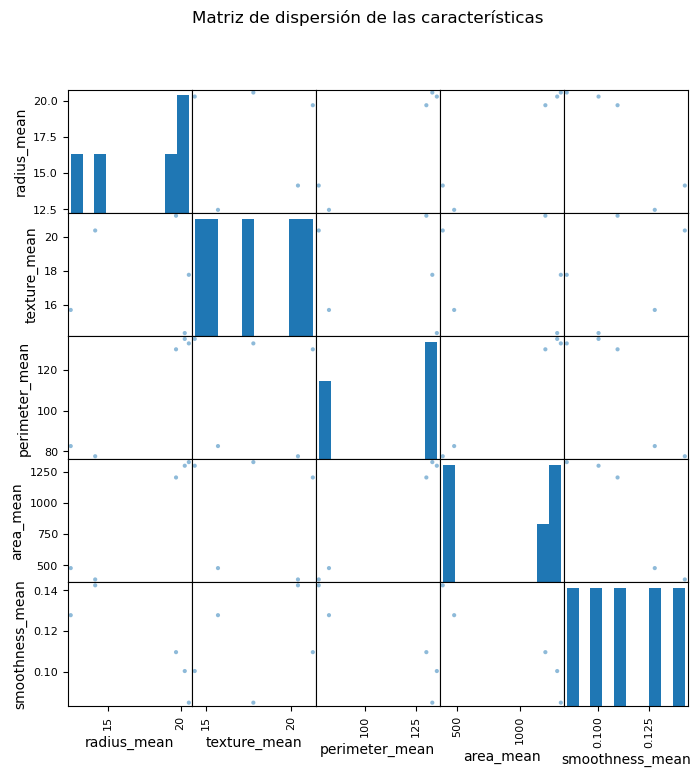

In [30]:
# Visualización Básica
pd.plotting.scatter_matrix(df.iloc[1:6, 1:6], figsize=(8,8))
plt.suptitle("Matriz de dispersión de las características")
plt.show()

In [33]:
# Separar datos en entrenamiento y prueba

# División estratificada para respetar la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

# Escalado (opcional pero recomendable para modelos sensibles a escalas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
## 4. Entrenamiento y evaluación de modelos
# Utilizar varios algoritmos para comparar su exactitud y analizar matriz de confusión


--- RegLog ---
Tiempo de entrenamiento: 0.01794 segundos
Exactitud: 0.96
Reporte:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de confusión:
 [[71  1]
 [ 3 39]]


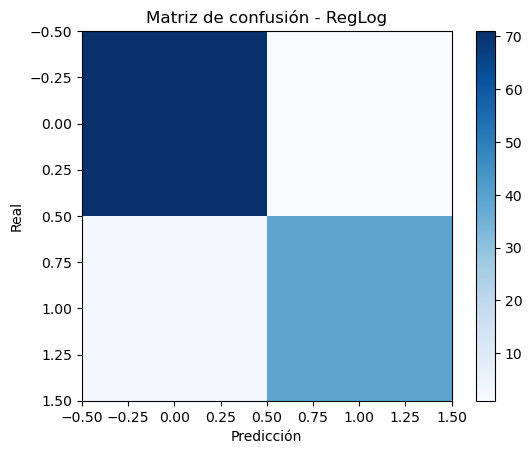


--- Arbol ---
Tiempo de entrenamiento: 0.02491 segundos
Exactitud: 0.91
Reporte:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93        72
           1       0.90      0.86      0.88        42

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114

Matriz de confusión:
 [[68  4]
 [ 6 36]]


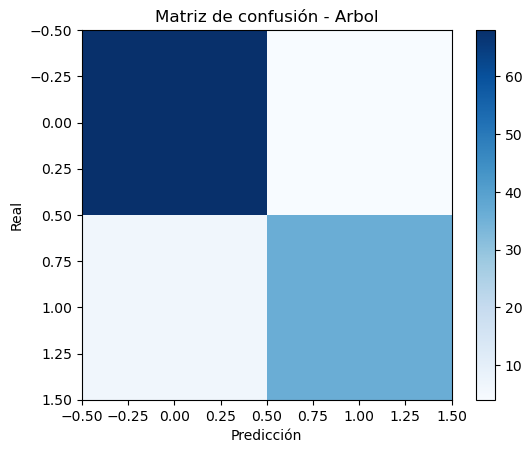


--- SVC ---
Tiempo de entrenamiento: 0.00498 segundos
Exactitud: 0.96
Reporte:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Matriz de confusión:
 [[71  1]
 [ 3 39]]


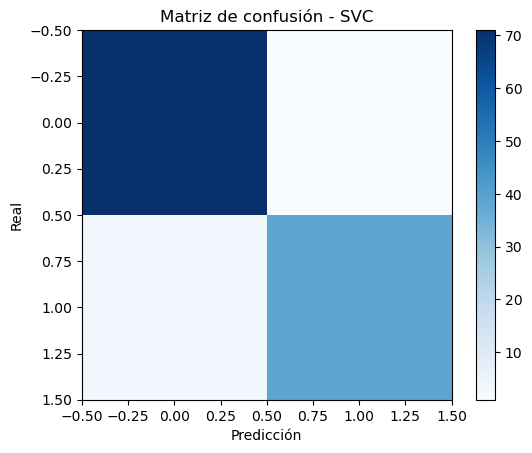


--- RandomForest ---
Tiempo de entrenamiento: 0.43554 segundos
Exactitud: 0.97
Reporte:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Matriz de confusión:
 [[72  0]
 [ 3 39]]


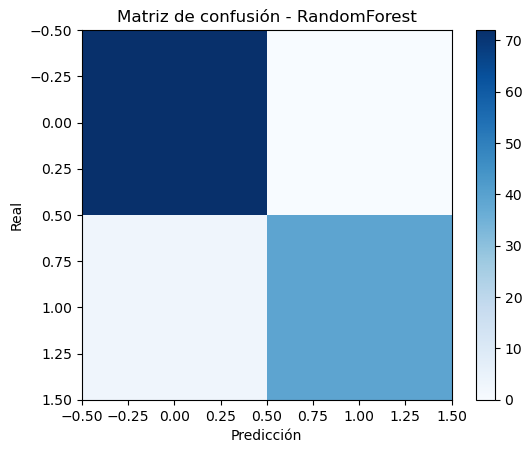

In [36]:
modelos = {
    "RegLog": LogisticRegression(max_iter=200),
    "Arbol": DecisionTreeClassifier(random_state=42),
    "SVC": SVC(),
    "RandomForest": RandomForestClassifier(random_state=42)
}

resultados = {}
tiempos_entrenamiento = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_scaled, y_train)
    fin = time.time()
    
    tiempo = fin - inicio
    tiempos_entrenamiento[nombre] = tiempo
    
    # Predicción y métricas
    pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    resultados[nombre] = acc
    
    print(f"\n--- {nombre} ---")
    print(f"Tiempo de entrenamiento: {tiempo:.5f} segundos")
    print(f"Exactitud: {acc:.2f}")
    print("Reporte:\n", classification_report(y_test, pred))
    
    cm = confusion_matrix(y_test, pred)
    print("Matriz de confusión:\n", cm)
    
    # Visualizar la matriz de confusión
    plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
    plt.title(f"Matriz de confusión - {nombre}")
    plt.colorbar()
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()


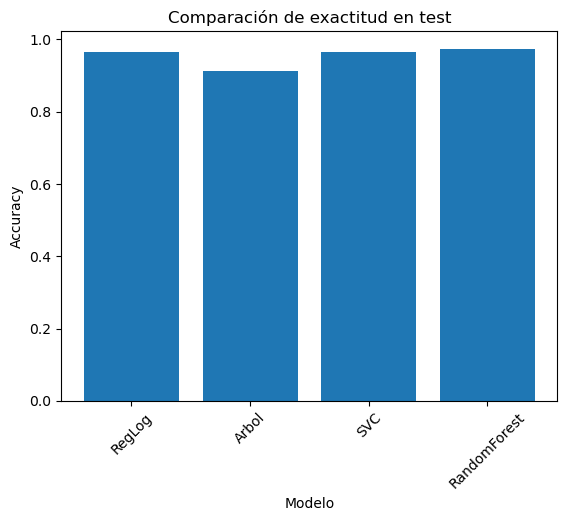

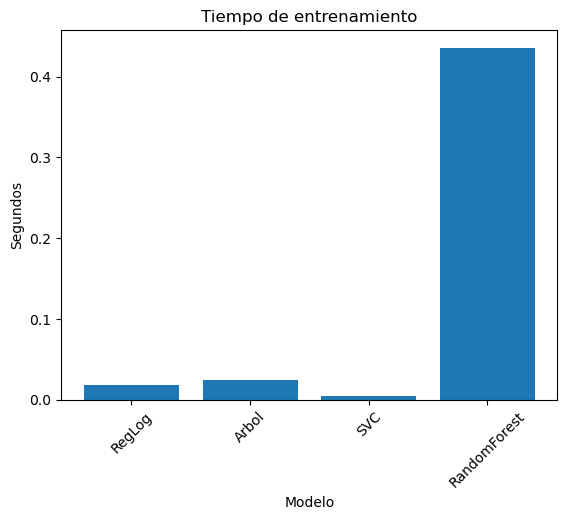

In [39]:
# 5. Comparación final de exactitud
# Gráfico de exactitud
plt.bar(resultados.keys(), resultados.values())
plt.title("Comparación de exactitud en test")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Gráfico de tiempos
plt.bar(tiempos_entrenamiento.keys(), tiempos_entrenamiento.values())
plt.title("Tiempo de entrenamiento")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.xticks(rotation=45)
plt.show()

In [40]:
# 7. Seleccionar el mejor modelo


# Encontrar el nombre del modelo con mejor accuracy
mejor_modelo_nombre = max(resultados, key=resultados.get)
mejor_modelo = modelos[mejor_modelo_nombre]

print("El mejor modelo es:", mejor_modelo_nombre)
print("Exactitud en test:", resultados[mejor_modelo_nombre])


El mejor modelo es: RandomForest
Exactitud en test: 0.9736842105263158


In [ ]:
# Crear la funcion que reciba las otras caracteristicas

In [41]:
def predecir_cancer_mama(caracteristicas, model, scaler):
    """
    Predice si una muestra es benigna (0) o maligna (1) usando un modelo entrenado.

    Parámetros:
    - caracteristicas: lista o array de valores numéricos (deben coincidir en orden y tamaño con X_train)
    - model: modelo de clasificación previamente entrenado
    - scaler: objeto StandardScaler entrenado con los datos

    Retorna:
    - Clase predicha: 0 (benigno) o 1 (maligno)
    """
    import numpy as np

    # Convertir a array con forma (1, n_features)
    X_nueva = np.array([caracteristicas])

    # Escalar la muestra
    X_nueva_scaled = scaler.transform(X_nueva)

    # Predecir
    pred_clase = model.predict(X_nueva_scaled)

    return pred_clase[0]  # 0 o 1


In [42]:
# Usamos una muestra real del test para ejemplo
muestra = X_test.iloc[0].values  # si X_test es DataFrame
# o simplemente: muestra = X_test[0]  # si es array

pred = predecir_cancer_mama(muestra, model=mejor_modelo, scaler=scaler)

print("Diagnóstico predicho:", "Maligno (1)" if pred == 1 else "Benigno (0)")


Diagnóstico predicho: Benigno (0)


C:\Users\Anton\anaconda3\lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [43]:
print(muestra)

[1.141e+01 1.082e+01 7.334e+01 4.033e+02 9.373e-02 6.685e-02 3.512e-02
 2.623e-02 1.667e-01 6.113e-02 1.408e-01 4.607e-01 1.103e+00 1.050e+01
 6.040e-03 1.529e-02 1.514e-02 6.460e-03 1.344e-02 2.206e-03 1.282e+01
 1.597e+01 8.374e+01 5.105e+02 1.548e-01 2.390e-01 2.102e-01 8.958e-02
 3.016e-01 8.523e-02]
